In [1]:
%pip install transformers
%pip install datasets
%pip install torch --index-url https://download.pytorch.org/whl/cu118
%pip install catboost
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kiril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kiril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kiril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kiril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kiril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import math
import random
import pandas as pd
import numpy as np
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from collections import Counter, defaultdict
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                            recall_score, confusion_matrix, roc_auc_score, 
                            classification_report, roc_curve, auc)
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
atd_dataset = datasets.load_dataset("Jinyan1/COLING_2025_MGT_en")

In [5]:
atd_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
        num_rows: 610767
    })
    dev: Dataset({
        features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
        num_rows: 261758
    })
})

In [6]:
print("Список доменов:")
print(atd_dataset["train"].unique('sub_source'))
print()
print("Список моделей-генераторов:")
print(atd_dataset["train"].unique('model'))
print()
print("Модели-генераторы в train и dev подмножествах совпадают:")
print(set(atd_dataset["train"].unique('model')) == set(atd_dataset["dev"].unique('model')))

Список доменов:
['reddit', 'squad', 'yelp', 'xsum', 'wikipedia', 'reddit_eli5', 'wp', 'roct', 'outfox', 'wikihow', 'sci_gen', 'eli5', 'arxiv', 'cmv', 'tldr', 'peerread', 'hswag', 'finance', 'open_qa', 'imdb', 'wiki_csai', 'dialogsum', 'medicine', 'cnn', 'pubmed']

Список моделей-генераторов:
['llama3-8b', 'human', 'gpt-35', 'GLM130B', '65B', 'text-davinci-003', 'gpt4', 'gpt4o', '7B', 'opt_350m', 'gpt-3.5-turbo', 'cohere', 'davinci', 'mixtral-8x7b', 'gpt_j', 'opt_2.7b', 'flan_t5_small', 'flan_t5_xxl', 'bloomz', 't0_11b', 'opt_iml_max_1.3b', 'text-davinci-002', 'flan_t5_base', 'flan_t5_large', 'bloom_7b', 'opt_30b', 'opt_iml_30b', 'opt_1.3b', 'gpt_neox', 'dolly', '30B', 't0_3b', 'opt_6.7b', 'llama3-70b', 'gemma-7b-it', 'flan_t5_xl', '13B', 'gemma2-9b-it', 'opt_13b', 'dolly-v2-12b', 'opt_125m']

Модели-генераторы в train и dev подмножествах совпадают:
True


In [7]:
models_of_interest = {"train": ["human", "gpt-3.5-turbo", "gpt4", "gemma2-9b-it", "llama3-70b"],
                      "dev": ["human", "mixtral-8x7b", "gpt4o", "gemma-7b-it", "llama3-8b"]}
sources_of_interest = {"train": ["reddit"],
                       "dev": ["reddit", "wikipedia", "wikihow"]}

splits = {"train": None, "dev": None}
n_samples = [2500, 1000]
i = 0

for split in splits:
    splits[split] = atd_dataset[split].filter(
        lambda sample: sample["model"] in models_of_interest[split] and sample["sub_source"] in sources_of_interest[split]
    )
    df = splits[split].to_pandas()
    sampled_df = df.groupby("model", group_keys=False).apply(
        lambda x: x.sample(n=min(n_samples[i], len(x)), random_state=42)
    ).reset_index(drop=True)
    splits[split] = datasets.Dataset.from_pandas(sampled_df)
    i += 1

In [8]:
splits

{'train': Dataset({
     features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
     num_rows: 11252
 }),
 'dev': Dataset({
     features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
     num_rows: 5000
 })}

In [9]:
initial_df_train = pd.DataFrame(splits['train'])
initial_df_dev = pd.DataFrame(splits['dev'])

In [9]:
initial_df_train.sample(10)

,id,source,sub_source,lang,model,label,text
8742,1c7e8054-3a0d-40f5-a1eb-cebfb09d6938,m4gt,reddit,en,human,0,"As /u/Korvax_of_Myrmidon pointed out, most wil..."
7336,6bb2a20f-28d2-4fd5-8263-e2e06cbd93d2,m4gt,reddit,en,human,0,It became popular in the late 19th/early 20th ...
7055,c5d1c083-bdd3-483c-a449-0725983b0697,m4gt,reddit,en,human,0,This is a very interesting question.\nFrom a n...
3819,958d9b92-de33-40e0-904c-a0087297964e,m4gt,reddit,en,gpt-3.5-turbo,1,"During the Vietnam War, there were indeed inci..."
6682,10f0f94c-6ed6-48b6-95c7-b2836b450605,m4gt,reddit,en,human,0,Corporate Welfare is a negative term to descri...
7042,11a8531b-006c-4460-a714-1ab87928ae5a,m4gt,reddit,en,human,0,"In 1972, there was a shift from gross to net h..."
1068,b32d1dd2-8005-4754-baf2-0e30137ce753,m4gt,reddit,en,gemma2-9b-it,1,While the concept of monkeys riding goats migh...
9324,b2ebaab1-2a59-458e-ba7f-cbba299814d9,m4gt,reddit,en,llama3-70b,1,There is no credible evidence to suggest that ...
668,ec666c67-7044-40ca-a38e-43e22216f41e,m4gt,reddit,en,gemma2-9b-it,1,The decision not to repatriate the vast majori...
8752,98eff431-3224-4a31-b8cf-1ceb86d75e4d,m4gt,reddit,en,human,0,"A long time ago, an old gentleman by the name ..."


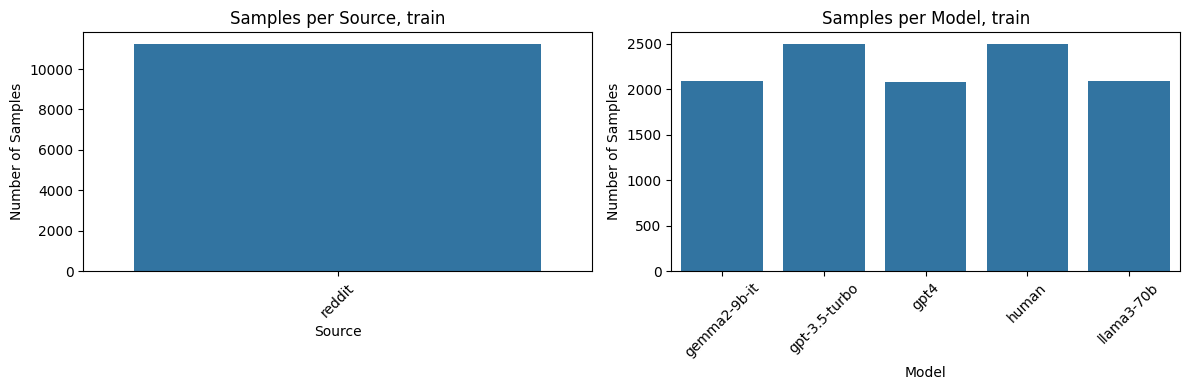

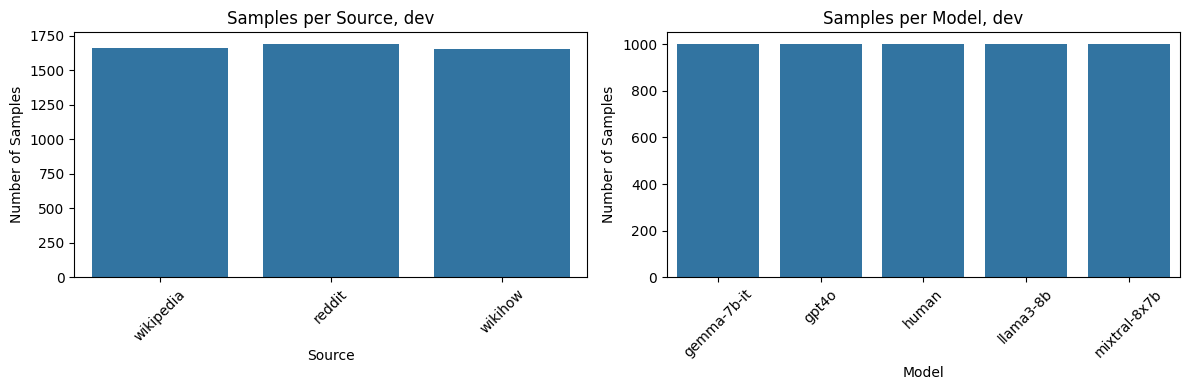

In [10]:
for split in splits:
    filtered_subset = splits[split]

    sources = [sample["sub_source"] for sample in filtered_subset]
    models = [sample["model"] for sample in filtered_subset]

    source_counts = Counter(sources)
    model_counts = Counter(models)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(x=list(source_counts.keys()), y=list(source_counts.values()), ax=axes[0])
    axes[0].set_title("Samples per Source, " + split)
    axes[0].set_xlabel("Source")
    axes[0].set_ylabel("Number of Samples")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(x=list(model_counts.keys()), y=list(model_counts.values()), ax=axes[1])
    axes[1].set_title("Samples per Model, " + split)
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Number of Samples")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [11]:
model_p = AutoModelForCausalLM.from_pretrained("microsoft/phi-1.5", #"gpt2",
                                             torch_dtype="auto",
                                             trust_remote_code=True,
                                             output_hidden_states=True
                                            )
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-1.5", #"gpt2",
                                          trust_remote_code=True
                                          )

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_p = model_p.to(device)

cuda


In [13]:
def calculate_perplexity(text, model, tokenizer, device):
    """
    Calculate perplexity of text using a language model.
    
    Args:
        text: Input text string
        model: Language model for perplexity calculation
        tokenizer: Tokenizer for the model
        device: Device to run computation on (cuda/cpu)
    
    Returns:
        Perplexity value (float)
    """
    # Токенизация
    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    encodings = {k: v.to(device) for k, v in encodings.items()}

    # Вычисление mean negative log-likelihood (nll) per token
    # (стандартный loss для LLM в библиотеке transformers)
    input_ids = encodings["input_ids"]
    with torch.no_grad():
        outputs = model(**encodings, labels=input_ids)
        neg_log_likelihood = outputs.loss.item()

    # Перплексия вычисляется как e ^ nll
    perplexity = math.exp(neg_log_likelihood) 
    return perplexity

In [14]:
perplexity_per_sample = defaultdict(list)

for split in splits: # train, dev
    for sample in tqdm(splits[split]):
        text = sample["text"]
        model_type = sample["model"]  # 'human' or model name
        sub_source = sample["sub_source"]

        try:
            ppl = calculate_perplexity(text, model_p, tokenizer, device)
            perplexity_per_sample[split].append({
                "perplexity": ppl,
                "model": model_type,
                "sub_source": sub_source
            })
        except Exception as e:
            print(f"Error processing sample: {e}")

100%|██████████| 5000/5000 [12:37<00:00,  6.60it/s]


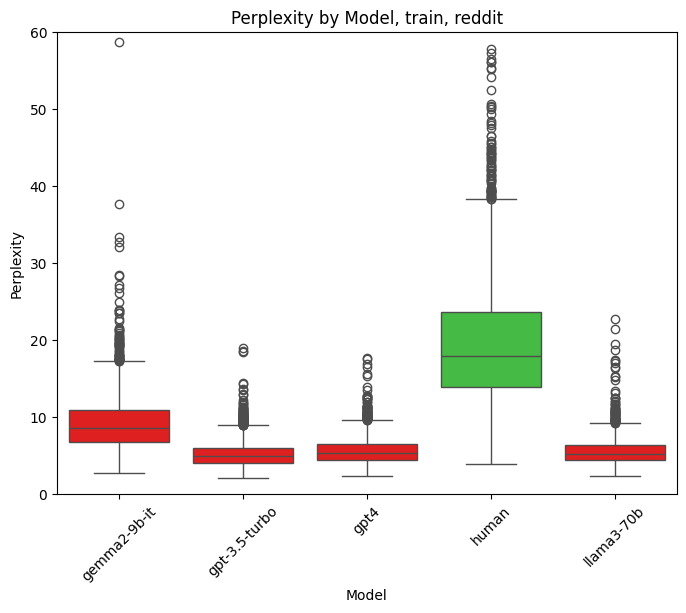

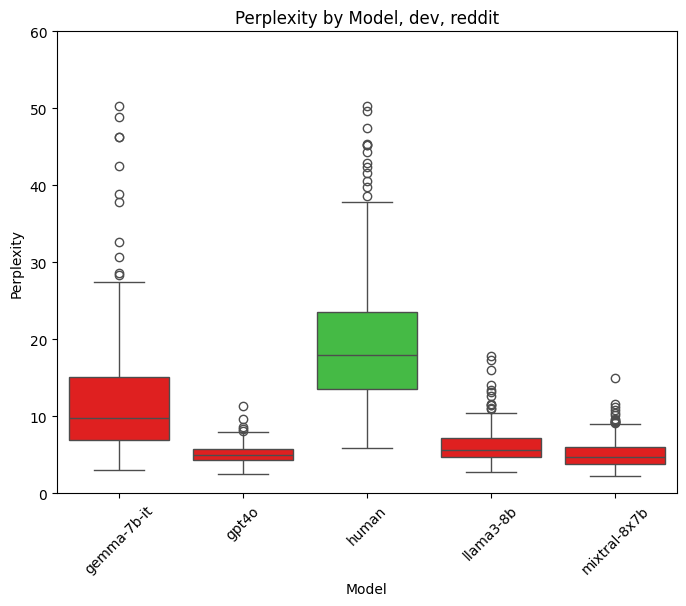

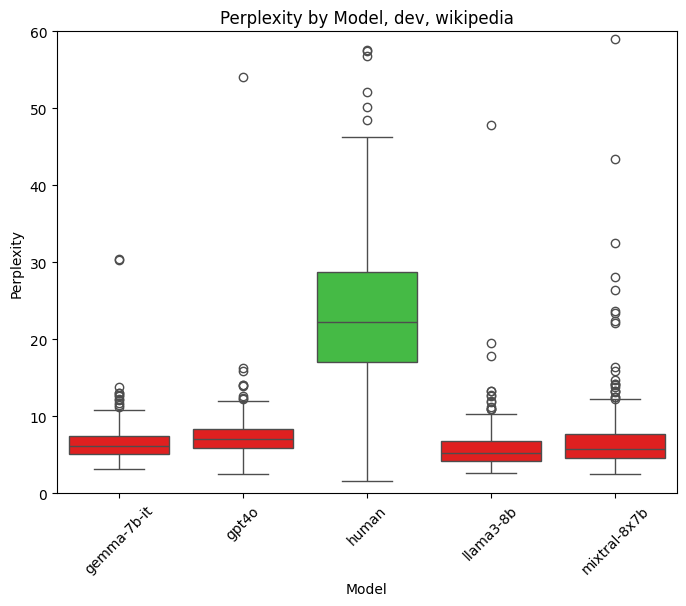

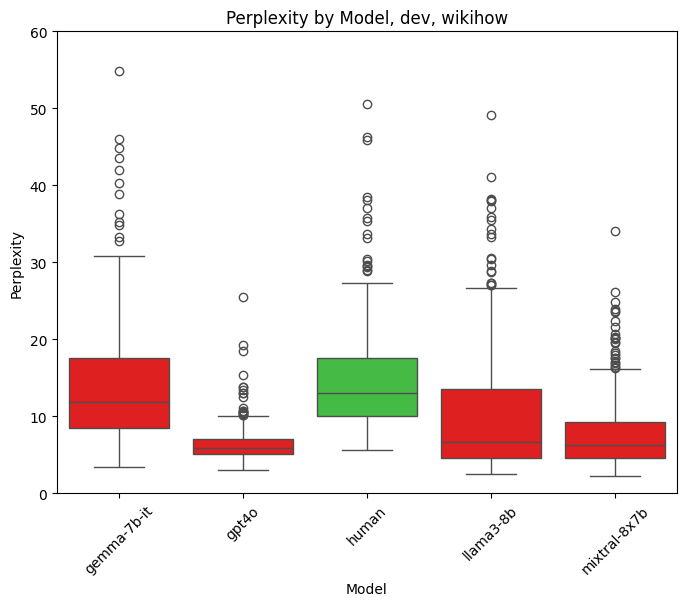

In [15]:
for split in splits: # train, dev
    for sub_source in sources_of_interest[split]: # wikipedia, reddit etc
        df = pd.DataFrame(perplexity_per_sample[split])
        df = df[df["sub_source"] == sub_source]
        df["model"] = pd.Categorical(df["model"], categories=sorted(df["model"].unique()), ordered=True)

        plt.figure(figsize=(8, 6))
        palette = {}
        for model in df["model"].unique():
            palette[model] = "red"
        palette["human"] = "limegreen"
        sns.boxplot(x="model", y="perplexity", data=df, palette=palette)
        plt.title("Perplexity by Model, " + split + ", " + sub_source)
        plt.xlabel("Model")
        plt.ylabel("Perplexity")
        plt.ylim(0, 60)
        plt.tick_params(axis="x", rotation=45)
        plt.show()

In [16]:
import catboost

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
stop_words_list = [
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 
    'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 
    'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 
    'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 
    'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 
    'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 
    'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 
    'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 
    'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 
    'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 
    't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 
    'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 
    'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 
    'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', 
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
]

In [18]:
vectorizer = TfidfVectorizer(max_features=15000, stop_words=stop_words_list, norm=None)
vector_text_train = vectorizer.fit_transform(initial_df_train['text'].values)
vector_text_dev = vectorizer.transform(initial_df_dev['text'].values)

In [19]:
perplexities_train = np.array([value['perplexity'] for value in perplexity_per_sample['train']])
perplexities_dev = np.array([value['perplexity'] for value in perplexity_per_sample['dev']])

In [20]:
detector_train_df = pd.DataFrame(perplexity_per_sample["train"])
detector_train_df["label"] = (detector_train_df["model"] == "human").astype(int)

detector_dev_df = pd.DataFrame(perplexity_per_sample["dev"])
detector_dev_df["label"] = (detector_dev_df["model"] == "human").astype(int)

In [21]:
label_train = np.array(detector_train_df["label"])
label_dev = np.array(detector_dev_df["label"])

In [22]:
from scipy.sparse import csr_matrix, hstack
import re

# Extract additional text features
def extract_text_features(texts):
    """
    Extract additional features from texts that may help with classification.
    
    Returns:
        numpy array with features: [text_length, word_count, sentence_count, 
                                   avg_word_length, punctuation_count, 
                                   uppercase_ratio, digit_count]
    """
    features = []
    for text in texts:
        text_length = len(text)
        words = text.split()
        word_count = len(words)
        sentences = re.split(r'[.!?]+', text)
        sentence_count = max(1, len([s for s in sentences if s.strip()]))
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        punctuation_count = sum(1 for c in text if c in '.,!?;:')
        uppercase_ratio = sum(1 for c in text if c.isupper()) / max(1, len(text))
        digit_count = sum(1 for c in text if c.isdigit())
        
        features.append([
            text_length, word_count, sentence_count, avg_word_length,
            punctuation_count, uppercase_ratio, digit_count
        ])
    return np.array(features)

# Extract text features
text_features_train = extract_text_features(initial_df_train['text'].values)
text_features_dev = extract_text_features(initial_df_dev['text'].values)

# Handle NaN perplexities (replace with median)
perplexities_train_clean = np.array([value['perplexity'] for value in perplexity_per_sample['train']])
perplexities_dev_clean = np.array([value['perplexity'] for value in perplexity_per_sample['dev']])

# Replace NaN with median
train_median_ppl = np.nanmedian(perplexities_train_clean)
dev_median_ppl = np.nanmedian(perplexities_dev_clean)
perplexities_train_clean = np.nan_to_num(perplexities_train_clean, nan=train_median_ppl)
perplexities_dev_clean = np.nan_to_num(perplexities_dev_clean, nan=dev_median_ppl)

# Create additional perplexity-based features
# Normalized perplexity (z-score)
train_ppl_mean = np.mean(perplexities_train_clean)
train_ppl_std = np.std(perplexities_train_clean) + 1e-8
perplexities_train_norm = (perplexities_train_clean - train_ppl_mean) / train_ppl_std
perplexities_dev_norm = (perplexities_dev_clean - train_ppl_mean) / train_ppl_std

# Log perplexity (often more stable)
perplexities_train_log = np.log1p(perplexities_train_clean)
perplexities_dev_log = np.log1p(perplexities_dev_clean)

# Combine all features
perplexities_train_sparse = csr_matrix(perplexities_train_clean.reshape(-1, 1))
perplexities_dev_sparse = csr_matrix(perplexities_dev_clean.reshape(-1, 1))
perplexities_train_norm_sparse = csr_matrix(perplexities_train_norm.reshape(-1, 1))
perplexities_dev_norm_sparse = csr_matrix(perplexities_dev_norm.reshape(-1, 1))
perplexities_train_log_sparse = csr_matrix(perplexities_train_log.reshape(-1, 1))
perplexities_dev_log_sparse = csr_matrix(perplexities_dev_log.reshape(-1, 1))
text_features_train_sparse = csr_matrix(text_features_train)
text_features_dev_sparse = csr_matrix(text_features_dev)

# Stack all features together
detector_train_data = hstack([
    vector_text_train, 
    perplexities_train_sparse,
    perplexities_train_norm_sparse,
    perplexities_train_log_sparse,
    text_features_train_sparse
])
detector_dev_data = hstack([
    vector_text_dev, 
    perplexities_dev_sparse,
    perplexities_dev_norm_sparse,
    perplexities_dev_log_sparse,
    text_features_dev_sparse
])

print(f"Train features shape: {detector_train_data.shape}")
print(f"Dev features shape: {detector_dev_data.shape}")

Train features shape: (11252, 15010)
Dev features shape: (5000, 15010)


In [23]:
np.size(label_train, axis=0)
np.size(detector_train_data, axis=0)

11252

In [24]:
detector_model_cb = catboost.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=150,
    use_best_model=True
)

In [25]:
detector_model_cb.fit(detector_train_data,
                       label_train,
                       early_stopping_rounds=150, use_best_model=True,
                       eval_set=(detector_dev_data, label_dev))

y_train_pred_cb = detector_model_cb.predict_proba(detector_train_data)[:,1]
y_test_pred_cb = detector_model_cb.predict_proba(detector_dev_data)[:,1]

0:	learn: 0.8828510	test: 0.6964064	best: 0.6964064 (0)	total: 336ms	remaining: 5m 35s
100:	learn: 0.9642714	test: 0.7703451	best: 0.7768523 (38)	total: 13.2s	remaining: 1m 57s
200:	learn: 0.9700983	test: 0.7769231	best: 0.7782068 (141)	total: 28.1s	remaining: 1m 51s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.7782067782
bestIteration = 141

Shrink model to first 142 iterations.


In [26]:
thresholds = np.sort(y_test_pred_cb)

best_threshold = None
best_f1 = 0

for threshold in thresholds:
    preds = (y_test_pred_cb > threshold).astype(int)
    f1 = f1_score(label_dev, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold}, Train F1: {best_f1:.3f}")

Best threshold: 0.581495031262896, Train F1: 0.783


In [27]:
preds_train = (y_train_pred_cb > best_threshold).astype(int)
preds_dev = (y_test_pred_cb > best_threshold).astype(int)

In [28]:
train_accuracy = accuracy_score(label_train, preds_train)
train_f1 = f1_score(label_train, preds_train)

dev_accuracy = accuracy_score(label_dev, preds_dev)
dev_f1 = f1_score(label_dev, preds_dev)
print(f"Train Accuracy (Threshold={best_threshold:.2f}): {train_accuracy:.3f}")
print(f"Train F1 (Threshold={best_threshold:.2f}): {train_f1:.3f}")
print()
print(f"Dev Accuracy (Threshold={best_threshold:.2f}): {dev_accuracy:.3f}")
print(f"Dev F1 (Threshold={best_threshold:.2f}): {dev_f1:.3f}")

Train Accuracy (Threshold=0.58): 0.986
Train F1 (Threshold=0.58): 0.968

Dev Accuracy (Threshold=0.58): 0.901
Dev F1 (Threshold=0.58): 0.783


In [29]:
test_data = detector_dev_df.copy()
test_data['preds'] = preds_dev
test_data['pred_proba'] = y_test_pred_cb

In [30]:
model_accuracy = test_data.groupby('model').apply(
    lambda x: accuracy_score(x['label'], x['preds'])
)

source_accuracy = test_data.groupby('sub_source').apply(
    lambda x: accuracy_score(x['label'], x['preds'])
)

print("\nPer-Model Accuracy:")
print(model_accuracy.sort_values())

print("\nPer-Source Accuracy:")
print(source_accuracy.sort_values())


Per-Model Accuracy:
model
gemma-7b-it     0.819
human           0.891
llama3-8b       0.899
mixtral-8x7b    0.920
gpt4o           0.977
dtype: float64

Per-Source Accuracy:
sub_source
wikihow      0.751511
wikipedia    0.962583
reddit       0.987567
dtype: float64
